# Black-Scholes Option Pricing: Analytical vs Monte Carlo

Objective

This project implements the Black-Scholes analytical pricing model
and a Monte Carlo simulation to price European call options.

The two approaches will be compared in terms of:

- Option price
- Convergence
- Pricing error
- Computational efficiency
- Sensitivity to model parameters

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [34]:
# Option parameters

S0 = 100       # Current stock price
K = 100        # Strike price
T = 1          # Time to maturity (years)
r = 0.05       # Risk-free interest rate
sigma = 0.20   # Volatility

print("Stock Price:", S0)
print("Strike Price:", K)
print("Time to Maturity:", T)
print("Risk-Free Rate:", r)
print("Volatility:", sigma)
print("Setup complete.")

Stock Price: 100
Strike Price: 100
Time to Maturity: 1
Risk-Free Rate: 0.05
Volatility: 0.2
Setup complete.


In [35]:
import numpy as np
from scipy.stats import norm

d1 = (
    np.log(S0 / K)
    + (r + 0.5 * sigma**2) * T
) / (sigma * np.sqrt(T))

print("d1 =", d1)

d1 = 0.35000000000000003


In [36]:
d2 = d1 - sigma * np.sqrt(T)

print("d2 =", d2)

d2 = 0.15000000000000002


In [37]:
call_price = (
    S0 * norm.cdf(d1)
    - K * np.exp(-r * T) * norm.cdf(d2)
)

print("Black-Scholes Call Price:", call_price)

Black-Scholes Call Price: 10.450583572185565


## Monte Carlo Simulation

Instead of using the analytical Black-Scholes formula, we estimate
the option price by simulating many possible future stock prices.

In [38]:
# Number of Monte Carlo simulations

n_simulations = 10_000

print("Number of simulations:", n_simulations)

Number of simulations: 10000


## Simulating Future Stock Prices
We assume the stock price follows geometric Brownian motion:

$$
S_T = S_0 e^{(r-\frac{1}{2}\sigma^2)T+\sigma\sqrt{T}Z}
$$

where $Z$ is drawn from a standard normal distribution.

In [39]:
# Number of Monte Carlo simulations
n_simulations = 10_000

# Generate random numbers from a standard normal distribution
Z = np.random.standard_normal(n_simulations)

print("First 10 random values:")
print(Z[:10])

First 10 random values:
[ 0.16917185 -0.12150516  1.15662527  0.20008579  0.86461069  1.40578307
  0.53227027 -0.47922124 -0.94466936 -1.6717347 ]


In [40]:
# Simulate stock prices at maturity

ST = S0 * np.exp(
    (r - 0.5 * sigma**2) * T
    + sigma * np.sqrt(T) * Z
)

print("First 10 simulated stock prices:")
print(ST[:10])

First 10 simulated stock prices:
[106.59158376 100.57152388 129.8649729  107.25265833 122.49770862
 136.5002982  114.6202214   93.62766797  85.30527679  73.76049167]


In [41]:
# Calculate the payoff of the call option

payoffs = np.maximum(ST - K, 0)

print("First 10 simulated payoffs:")
print(payoffs[:10])

First 10 simulated payoffs:
[ 6.59158376  0.57152388 29.8649729   7.25265833 22.49770862 36.5002982
 14.6202214   0.          0.          0.        ]


In [42]:
# Average payoff across all simulations

average_payoff = np.mean(payoffs)

print("Average payoff:", average_payoff)

Average payoff: 11.273312187529042


In [43]:
# Discount the expected payoff back to today

monte_carlo_price = np.exp(-r * T) * average_payoff

print("Monte Carlo Call Price:", monte_carlo_price)

Monte Carlo Call Price: 10.723506264360136


In [44]:
# Compare Monte Carlo and Black-Scholes

print("Black-Scholes Price:", call_price)
print("Monte Carlo Price:", monte_carlo_price)
print("Difference:", monte_carlo_price - call_price)

Black-Scholes Price: 10.450583572185565
Monte Carlo Price: 10.723506264360136
Difference: 0.2729226921745713


## Monte Carlo Convergence

Monte Carlo pricing is a numerical estimation method.
Because the estimate depends on random simulations, the result
will generally differ from the analytical Black-Scholes price.

We investigate how the pricing error changes as the number
of simulations increases.

In [45]:
# Set a random seed for reproducibility

np.random.seed(42)

simulation_sizes = [10_000, 100_000, 1_000_000]

results = []

for n in simulation_sizes:
    
    Z = np.random.standard_normal(n)
    
    ST = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )
    
    payoffs = np.maximum(ST - K, 0)
    
    mc_price = np.exp(-r * T) * np.mean(payoffs)
    
    error = mc_price - call_price
    
    results.append((n, mc_price, error))

print("Simulation Size | Monte Carlo Price | Error")

for n, price, error in results:
    print(f"{n:>15,} | {price:>17.6f} | {error:>10.6f}")
    

Simulation Size | Monte Carlo Price | Error
         10,000 |         10.450170 |  -0.000414
        100,000 |         10.481812 |   0.031228
      1,000,000 |         10.439114 |  -0.011470


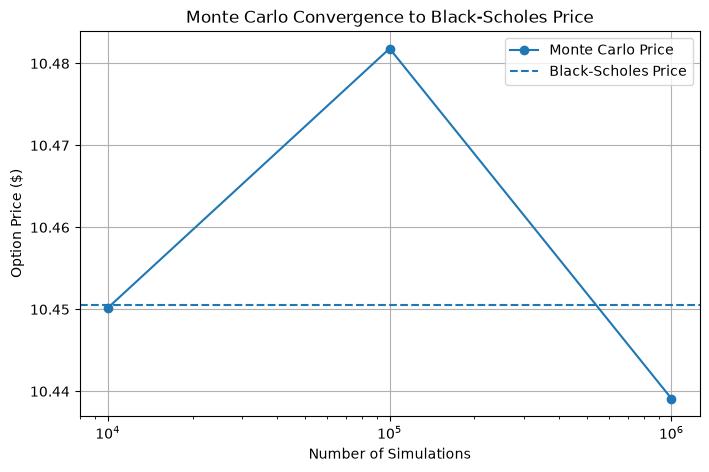

In [46]:
import matplotlib.pyplot as plt

# Extract results for plotting
simulation_counts = [result[0] for result in results]
mc_prices = [result[1] for result in results]

plt.figure(figsize=(8, 5))

plt.plot(
    simulation_counts,
    mc_prices,
    marker="o",
    label="Monte Carlo Price"
)

plt.axhline(
    y=call_price,
    linestyle="--",
    label="Black-Scholes Price"
)

plt.xscale("log")

plt.xlabel("Number of Simulations")
plt.ylabel("Option Price ($)")
plt.title("Monte Carlo Convergence to Black-Scholes Price")

plt.legend()
plt.grid(True)

plt.show()

In [47]:
# Calculate absolute pricing error

absolute_errors = [
    abs(result[2]) for result in results
]

for n, error in zip(simulation_counts, absolute_errors):
    print(f"{n:,} simulations → Absolute Error: ${error:.6f}")

10,000 simulations → Absolute Error: $0.000414
100,000 simulations → Absolute Error: $0.031228
1,000,000 simulations → Absolute Error: $0.011470


In [48]:
# Calculate the 95% confidence interval

discounted_payoffs = np.exp(-r * T) * payoffs

sample_std = np.std(discounted_payoffs, ddof=1)

standard_error = sample_std / np.sqrt(len(discounted_payoffs))

confidence_level = 1.96

ci_lower = monte_carlo_price - confidence_level * standard_error
ci_upper = monte_carlo_price + confidence_level * standard_error

print("Monte Carlo Price:", monte_carlo_price)
print("Standard Error:", standard_error)
print("95% Confidence Interval:")
print(f"${ci_lower:.4f} to ${ci_upper:.4f}")


Monte Carlo Price: 10.723506264360136
Standard Error: 0.014709100335606327
95% Confidence Interval:
$10.6947 to $10.7523


In [49]:
# Fresh 1,000,000-simulation Monte Carlo run

np.random.seed(42)

n_simulations = 1_000_000

Z = np.random.standard_normal(n_simulations)

ST = S0 * np.exp(
    (r - 0.5 * sigma**2) * T
    + sigma * np.sqrt(T) * Z
)

payoffs = np.maximum(ST - K, 0)

discounted_payoffs = np.exp(-r * T) * payoffs

monte_carlo_price = np.mean(discounted_payoffs)

print("Monte Carlo Price:", monte_carlo_price)

Monte Carlo Price: 10.434157688982825


In [50]:
# Calculate the 95% confidence interval

sample_std = np.std(discounted_payoffs, ddof=1)

standard_error = sample_std / np.sqrt(n_simulations)

ci_lower = monte_carlo_price - 1.96 * standard_error
ci_upper = monte_carlo_price + 1.96 * standard_error

print("Monte Carlo Price:", monte_carlo_price)
print("Standard Error:", standard_error)
print("95% Confidence Interval:")
print(f"${ci_lower:.4f} to ${ci_upper:.4f}")


Monte Carlo Price: 10.434157688982825
Standard Error: 0.014699813245467677
95% Confidence Interval:
$10.4053 to $10.4630


## Greeks

Greeks measure how sensitive an option's theoretical value is
to changes in different model parameters.

In [51]:
# Calculate Delta

delta = norm.cdf(d1)

print("Call Delta:", delta)

Call Delta: 0.6368306511756191


In [52]:
# Calculate Gamma

gamma = norm.pdf(d1) / (S0 * sigma * np.sqrt(T))

print("Call Gamma:", gamma)

Call Gamma: 0.018762017345846895


In [53]:
# Calculate Vega

vega = S0 * norm.pdf(d1) * np.sqrt(T) / 100

print("Call Vega:", vega)

Call Vega: 0.3752403469169379


In [54]:
# Calculate Theta

theta = (
    -(S0 * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    - r * K * np.exp(-r * T) * norm.cdf(d2)
)

print("Call Theta:", theta)

Call Theta: -6.414027546438197


In [55]:
# Calculate Rho

rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100

print("Call Rho:", rho)

Call Rho: 0.5323248154537634


## Sensitivity Analysis

This section examines how the Black-Scholes call price and Delta
change as the underlying stock price varies.


In [56]:
# Create a range of stock prices

stock_prices = np.linspace(80, 120, 41)

print(stock_prices)


[ 80.  81.  82.  83.  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.
  94.  95.  96.  97.  98.  99. 100. 101. 102. 103. 104. 105. 106. 107.
 108. 109. 110. 111. 112. 113. 114. 115. 116. 117. 118. 119. 120.]


In [57]:
# Calculate option price for each stock price

d1_sensitivity = (
    np.log(stock_prices / K)
    + (r + 0.5 * sigma**2) * T
) / (sigma * np.sqrt(T))

d2_sensitivity = d1_sensitivity - sigma * np.sqrt(T)

call_prices = (
    stock_prices * norm.cdf(d1_sensitivity)
    - K * np.exp(-r * T) * norm.cdf(d2_sensitivity)
)

print(call_prices)

[ 1.85941957  2.09074797  2.34129743  2.61163366  2.90225678  3.21359855
  3.54602029  3.89981167  4.27519032  4.6723021   5.09122208  5.53195623
  5.99444359  6.47855903  6.98411642  7.51087218  8.05852912  8.62674059
  9.2151147   9.82321874 10.45058357 11.09670813 11.76106375 12.44309852
 13.14224139 13.85790627 14.58949575 15.3364048  16.09802413 16.87374331
 17.66295374 18.46505126 19.27943855 20.10552734 20.94274025 21.79051253
 22.64829345 23.51554756 24.39175574 25.27641595 26.16904395]


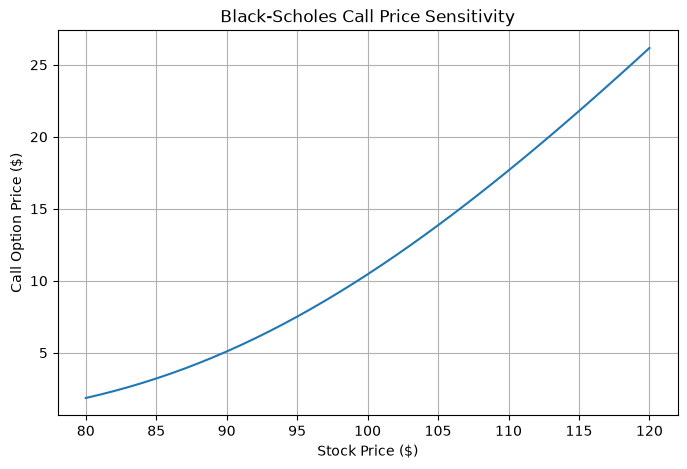

In [58]:
# Plot option price sensitivity to the stock price

plt.figure(figsize=(8, 5))

plt.plot(
    stock_prices,
    call_prices
)

plt.xlabel("Stock Price ($)")
plt.ylabel("Call Option Price ($)")
plt.title("Black-Scholes Call Price Sensitivity")

plt.grid(True)

plt.show()

In [59]:
# Calculate Delta across the stock-price range

delta_sensitivity = norm.cdf(d1_sensitivity)

print(delta_sensitivity)

[0.22192213 0.24083935 0.26035391 0.28040194 0.30091631 0.32182747
 0.34306428 0.36455475 0.38622685 0.40800919 0.42983173 0.45162636
 0.47332745 0.49487235 0.51620177 0.53726014 0.5579959  0.57836166
 0.59831437 0.61781543 0.63683065 0.65533028 0.67328891 0.69068538
 0.70750263 0.7237275  0.73935057 0.75436593 0.76877093 0.78256596
 0.79575417 0.80834127 0.82033524 0.83174608 0.8425856  0.85286715
 0.86260543 0.87181627 0.8805164  0.8887233  0.89645502]


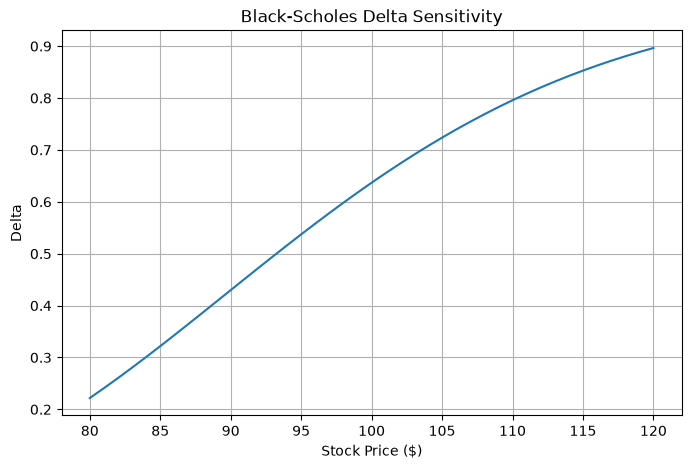

In [60]:
# Plot Delta sensitivity to the stock price

plt.figure(figsize=(8, 5))

plt.plot(
    stock_prices,
    delta_sensitivity
)

plt.xlabel("Stock Price ($)")
plt.ylabel("Delta")
plt.title("Black-Scholes Delta Sensitivity")

plt.grid(True)

plt.show()

In [61]:
# Calculate Gamma across the stock-price range

gamma_sensitivity = (
    norm.pdf(d1_sensitivity)
    / (stock_prices * sigma * np.sqrt(T))
)

print(gamma_sensitivity)

[0.01859823 0.01922623 0.01979224 0.02029261 0.02072452 0.02108594
 0.02137566 0.02159326 0.02173903 0.02181398 0.02181975 0.02175857
 0.02163317 0.02144674 0.02120283 0.02090532 0.0205583  0.02016605
 0.01973295 0.01926346 0.01876202 0.01823301 0.01768073 0.01710937
 0.01652293 0.01592524 0.01531992 0.01471036 0.01409971 0.01349087
 0.01288651 0.01228903 0.01170058 0.01112307 0.01055819 0.01000737
 0.00947184 0.00895263 0.00845055 0.00796627 0.00750025]


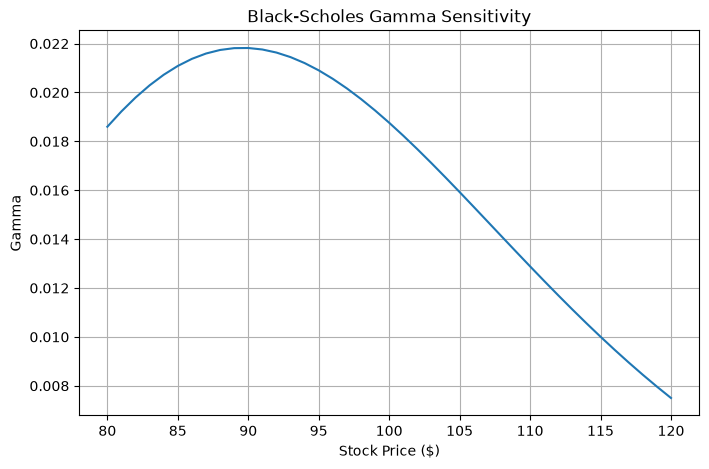

In [62]:
# Plot Gamma sensitivity to the stock price

plt.figure(figsize=(8, 5))

plt.plot(
    stock_prices,
    gamma_sensitivity
)

plt.xlabel("Stock Price ($)")
plt.ylabel("Gamma")
plt.title("Black-Scholes Gamma Sensitivity")

plt.grid(True)

plt.show()

## Black-Scholes vs Monte Carlo

The analytical Black-Scholes solution provides a benchmark
against which the Monte Carlo estimate can be evaluated.

The comparison examines both absolute and relative pricing error.

In [63]:
# Compare Black-Scholes and Monte Carlo

black_scholes_price = call_price

absolute_error = abs(monte_carlo_price - black_scholes_price)

relative_error = (
    absolute_error / black_scholes_price
) * 100

print(f"Black-Scholes Price: ${black_scholes_price:.4f}")
print(f"Monte Carlo Price:   ${monte_carlo_price:.4f}")
print(f"Absolute Error:      ${absolute_error:.4f}")
print(f"Relative Error:      {relative_error:.4f}%")

Black-Scholes Price: $10.4506
Monte Carlo Price:   $10.4342
Absolute Error:      $0.0164
Relative Error:      0.1572%


### Interpretation

The Monte Carlo estimate is close to the analytical Black-Scholes
price, with a relative pricing error of 0.1572%.

The remaining difference is attributable to Monte Carlo sampling
error. Increasing the number of simulations generally reduces the
standard error at a rate proportional to 1/sqrt(N).

## Model Assumptions and Limitations

### Key Assumptions

The Black-Scholes model relies on several simplifying assumptions:

1. **Constant volatility**  
   Volatility is assumed to remain constant throughout the option's life.

2. **Constant risk-free interest rate**  
   The risk-free rate is assumed to remain constant over the option's lifetime.

3. **Log-normal stock prices**  
   The model assumes the underlying asset follows geometric Brownian motion, meaning continuously compounded returns are normally distributed.

4. **No transaction costs**  
   The model assumes there are no brokerage fees, bid-ask spreads, or other trading costs.

5. **Continuous trading**  
   Investors are assumed to be able to trade continuously.

6. **European exercise**  
   The option can only be exercised at maturity.

7. **No dividends**  
   This implementation assumes the underlying stock does not pay dividends during the option's life.

### Limitations

These assumptions simplify real financial markets. In practice, volatility and
interest rates can change over time, transaction costs exist, and stock prices
can exhibit behaviour that differs from the model's assumptions.

Monte Carlo simulation also introduces sampling error. Although increasing the
number of simulations generally reduces this error, it increases computational
cost.

## Results Summary

| Metric | Result |
|---|---:|
| Black-Scholes Call Price | $10.4506 |
| Monte Carlo Call Price | $10.4342 |
| Monte Carlo Simulations | 1,000,000 |
| Absolute Pricing Error | $0.0164 |
| Relative Pricing Error | 0.1572% |
| Standard Error | $0.0147 |
| 95% Confidence Interval | $10.4053 – $10.4630 |
| Delta | 0.6368 |
| Gamma | 0.01876 |
| Vega | 0.3752 |
| Theta | -6.4140 |
| Rho | 0.5323 |

## Conclusion

This project implemented two approaches to pricing a European call option:
the analytical Black-Scholes model and a Monte Carlo simulation.

The Black-Scholes model produced a theoretical price of $10.4506, while the
1,000,000-simulation Monte Carlo model produced an estimate of $10.4342.
The relative pricing error was 0.1572%, demonstrating that the Monte Carlo
estimate converged closely to the analytical benchmark.

The project also examined the uncertainty associated with Monte Carlo
simulation through standard error and a 95% confidence interval.

The calculation of Delta, Gamma, Vega, Theta and Rho demonstrated how the
option value responds to changes in the underlying stock price, volatility,
time and interest rates.

Finally, sensitivity analysis showed the nonlinear relationship between the
underlying stock price and option value, as well as how Delta and Gamma vary
across different stock prices.

Overall, the project demonstrates the application of mathematical finance,
probability, numerical simulation and Python programming to an options pricing
problem.